## Import Libraries and Dataset

In [17]:
pip install seaborn


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import geopandas as gpd
import numpy as np
from sklearn.metrics import classification_report

df = gpd.read_file(r'data/road_points.gpkg')

## Data Preprocessing

### Create Longitude Latitude from Geometry Feature

In [19]:
df["longitude"] = df.geometry.x
df["latitude"] = df.geometry.y

### Data Conversion

In [20]:
dist_conver = ['preschool_dist', 'kind_dist', 'elem_dist','academy_dist', 'crossroads_dist','crosswalks_dist', 'tl_dist' ,'busstop_dist']
cat_conver = ['is_sidewalk', 'is_subway', 'is_accident', 'in_protection_zone', 'DVYN', 'ONSD']

for col in dist_conver:
    if col in df.columns: # Check if column exists to prevent KeyError
        df[col] = df[col].astype('float64')

for col in cat_conver:
    if col in df.columns: # Check if column exists to prevent KeyError
        df[col] = df[col].astype('category')

df = df.drop(columns=['geometry', 'accident_cnt'])

## Modeling

### Prep Block CV

In [21]:
n_blocks = 10

# Create the longitude bins
lon_bins = np.linspace(df['longitude'].min(), df['longitude'].max(), n_blocks + 1)
# Create the latitude bins
lat_bins = np.linspace(df['latitude'].min(), df['latitude'].max(), n_blocks + 1)

# Assign each data point to a longitude and latitude bin index
df['lon_bin'] = np.digitize(df['longitude'], bins=lon_bins)
df['lat_bin'] = np.digitize(df['latitude'], bins=lat_bins)

# Create a unique block_id for each grid cell
# This formula ensures each (lon_bin, lat_bin) pair gets a unique ID
df['block_id'] = (df['lon_bin'] * n_blocks) + df['lat_bin']

# Check the number of unique blocks created
print(f"Created {df['block_id'].nunique()} unique blocks.")

Created 58 unique blocks.


### BlockCV Visualization

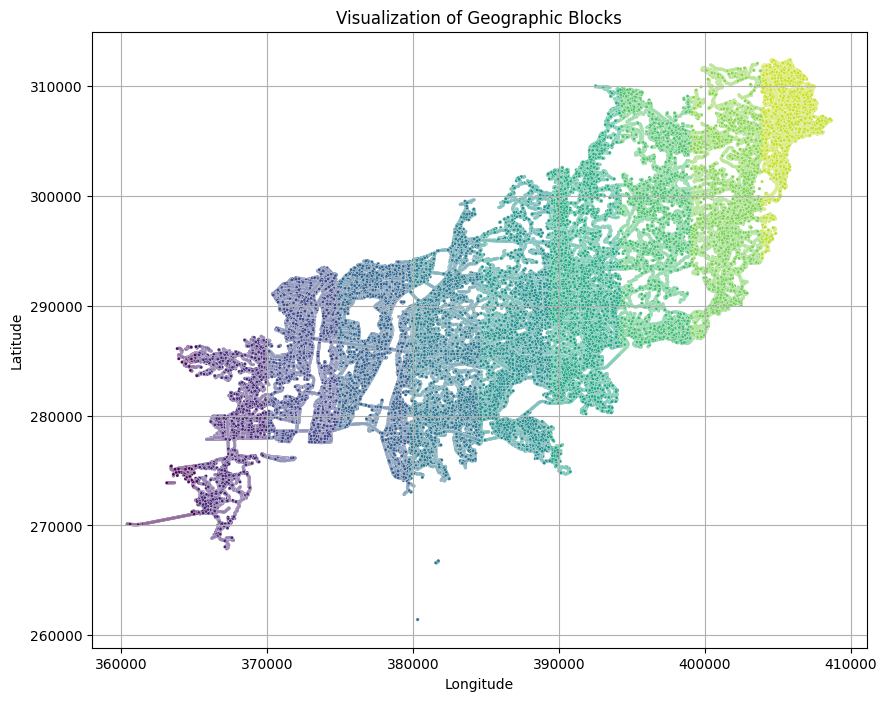

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='block_id',        # Color points by their assigned block
    palette='viridis',     # A color palette that works well for discrete groups
    legend=None,           # Turn off the legend as it would be too crowded
    s=5                    # Small point size
)
plt.title('Visualization of Geographic Blocks')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)
plt.show()

### Prepare Dataset for Modeling

In [23]:
# Assume 'df' is your DataFrame with accident data, latitude, and longitude
X = df.drop(columns=['is_accident', 'latitude', 'longitude']) # Features
y = df['is_accident']

### Train and Fit XGBoost, BlockCV Five-Fold

In [24]:
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import confusion_matrix
import xgboost as xgb


scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

# Define the model (you can use your tuned XGBoost model)
model = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    subsample=0.9,
    enable_categorical=True,
    colsample_bytree=0.8,
    random_state=42,
    min_child_weight = 1
)
#Best parameters found: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}
#Best spatial cross-validation ROC AUC: 0.9103
# The groups are our block IDs
groups = df['block_id']

# Define the CV splitter
# Let's use 5 splits. GroupKFold will partition the BLOCKS into 5 sets.
cv_splitter = GroupKFold(n_splits=5)

# Run the cross-validation
# We provide X, y, the cv splitter, and the groups array
print("Running Spatial Block CV to get predictions...")
# Use cross_val_predict to get out-of-fold predictions for each data point
# We use method='predict_proba' to get probabilities, which are needed for ROC AUC
# and give us flexibility to set our own threshold.
y_pred_probas = cross_val_predict(
    model,
    X,
    y,
    cv=cv_splitter,
    groups=groups,
    n_jobs=-1,
    method='predict_proba' # Get probabilities for the positive class
)[:, 1] # We only need the probabilities for the positive class (class 1)

# Now, you can define your own threshold to convert probabilities to class labels
# For example, using a standard 0.5 threshold:
threshold = 0.45
y_pred_labels_adjusted = (y_pred_probas >= threshold).astype(int)

# NOW these variables exist, and the final prints will work!
# Note: We compare the predictions against the original `y` vector.
print("\n--- Confusion Matrix (from Cross-Validation) ---")
print(confusion_matrix(y, y_pred_labels_adjusted))

print("\n--- Classification Report (from Cross-Validation) ---")
print(classification_report(y, y_pred_labels_adjusted))

Calculated scale_pos_weight: 2.88
Running Spatial Block CV to get predictions...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:30] WARN


--- Confusion Matrix (from Cross-Validation) ---
[[144641  33609]
 [  7576  54272]]

--- Classification Report (from Cross-Validation) ---
              precision    recall  f1-score   support

           0       0.95      0.81      0.88    178250
           1       0.62      0.88      0.72     61848

    accuracy                           0.83    240098
   macro avg       0.78      0.84      0.80    240098
weighted avg       0.86      0.83      0.84    240098



### Hyperparameter Tuning with GridSearch

In [25]:
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import xgboost as xgb
import numpy as np # Import numpy for array operations

# Assuming X, y, and df['block_id'] (for groups) are already defined from your context

# Calculate scale_pos_weight
# Ensure y is a pandas Series or similar if using .value_counts()
# If y is a numpy array, you might need np.bincount
if hasattr(y, 'value_counts'):
    scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]
else:
    # Assuming y contains 0s and 1s, count occurrences
    counts = np.bincount(y)
    scale_pos_weight = counts[0] / counts[1] if len(counts) > 1 else 1 # Handle case where only one class exists
print(f"Calculated scale_pos_weight: {scale_pos_weight:.2f}")

# The groups are our block IDs
groups = df['block_id']

# Define the CV splitter for GridSearch
cv_splitter_gridsearch = GroupKFold(n_splits=5)

# --- Define the Model for Grid Search ---
# We'll pass the base model to GridSearchCV, which will then clone it and set parameters.
# It's good practice to define a simple base model here.
base_model = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss', # eval_metric for internal evaluation during training
    # scale_pos_weight can be fixed or made part of the grid search if you want to tune it
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    enable_categorical=True # Keep this if your XGBoost version supports it for categorical features
)

# --- Define the Parameter Grid ---
# These are example parameters. Adjust them based on your understanding of XGBoost
# and previous tuning efforts.
param_grid = {
    'n_estimators': [100, 300, 500], # Number of boosting rounds
    'learning_rate': [0.01, 0.05, 0.1], # Step size shrinkage
    'max_depth': [3, 5, 7], # Maximum depth of a tree
    'colsample_bytree': [0.7, 0.8, 0.9], # Subsample ratio of columns when constructing each tree
    'subsample': [0.7, 0.8, 0.9], # Subsample ratio of the training instance
    'min_child_weight': [1, 3, 5] # Minimum sum of instance weight (hessian) needed in a child
}

# --- Set up GridSearchCV ---
# We'll optimize for ROC AUC, as it's often a good metric for imbalanced classification.
# n_jobs=-1 uses all available CPU cores.
print("\nRunning Spatial Block Grid Search for hyperparameter tuning...")
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=cv_splitter_gridsearch, # Use our GroupKFold splitter
    scoring='roc_auc', # Optimize for ROC AUC
    verbose=2, # Higher verbosity shows more details during the search
    n_jobs=-1, # Use all available cores
    return_train_score=True # Useful for debugging and understanding overfitting
)

# --- Run the Grid Search ---
# This will perform the cross-validation for each combination of parameters.
grid_search.fit(X, y, groups=groups) # Pass groups here for GroupKFold

print("\n--- Grid Search Results ---")
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation ROC AUC: {grid_search.best_score_:.4f}")

# You can access the best model directly:
best_model = grid_search.best_estimator_

# --- Evaluate the Best Model using cross_val_predict (as you had before) ---
# Now, let's use the best model found by GridSearchCV to get out-of-fold predictions
# and evaluate its performance, just like you were doing.

print("\nRunning Spatial Block CV with the best model to get predictions for final evaluation...")
y_pred_probas_best = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv_splitter_gridsearch, # Use the same splitter
    groups=groups,
    n_jobs=-1,
    method='predict_proba'
)[:, 1]

# You might want to re-evaluate the optimal threshold, or stick with your chosen one.
# For demonstration, let's use the one you had.
threshold = 0.45
y_pred_labels_adjusted_best = (y_pred_probas_best >= threshold).astype(int)

print("\n--- Confusion Matrix (from Best Model Spatial Cross-Validation) ---")
print(confusion_matrix(y, y_pred_labels_adjusted_best))

print("\n--- Classification Report (from Best Model Spatial Cross-Validation) ---")
print(classification_report(y, y_pred_labels_adjusted_best))

# Additionally, calculate ROC AUC using the probabilities
roc_auc_best = roc_auc_score(y, y_pred_probas_best)
print(f"\nROC AUC of Best Model on Spatial Cross-Validation: {roc_auc_best:.4f}")

# You can also inspect all results
# results = pd.DataFrame(grid_search.cv_results_)
# print(results.sort_values('mean_test_score', ascending=False).head())

Calculated scale_pos_weight: 2.88

Running Spatial Block Grid Search for hyperparameter tuning...
Fitting 5 folds for each of 729 candidates, totalling 3645 fits


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:42] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:42] WARN

[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   2.5s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   2.7s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   2.6s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   2.7s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   2.6s


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [21:06:45] WARN

[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   2.7s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.7; total time=   2.7s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   2.8s


...

[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=7, min_child_weight=5, n_estimators=500, subsample=0.8; total time=  22.1s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=7, min_child_weight=5, n_estimators=500, subsample=0.8; total time=  19.9s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=7, min_child_weight=5, n_estimators=500, subsample=0.9; total time=  18.6s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=7, min_child_weight=5, n_estimators=500, subsample=0.8; total time=  18.7s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=7, min_child_weight=5, n_estimators=500, subsample=0.9; total time=  18.3s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=7, min_child_weight=5, n_estimators=500, subsample=0.9; total time=  18.6s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_depth=7, min_child_weight=5, n_estimators=500, subsample=0.9; total time=  18.1s
[CV] END colsample_bytree=0.9, learning_rate=0.1, max_d

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:46:35] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Grid Search Results ---
Best parameters found: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.9}
Best cross-validation ROC AUC: 0.9154

Running Spatial Block CV with the best model to get predictions for final evaluation...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:46:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:46:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:46:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [22:46:37] WARN


--- Confusion Matrix (from Best Model Spatial Cross-Validation) ---
[[146218  32032]
 [  7325  54523]]

--- Classification Report (from Best Model Spatial Cross-Validation) ---
              precision    recall  f1-score   support

           0       0.95      0.82      0.88    178250
           1       0.63      0.88      0.73     61848

    accuracy                           0.84    240098
   macro avg       0.79      0.85      0.81    240098
weighted avg       0.87      0.84      0.84    240098


ROC AUC of Best Model on Spatial Cross-Validation: 0.9159


### Overnight GridSearchCV

In [26]:
# import numpy as np
# import xgboost as xgb
# from sklearn.model_selection import GridSearchCV, GroupKFold
# import joblib
#
# # --- 1. Prepare Data, Groups, and CV Splitter (from before) ---
# X = df.drop(columns=['is_accident', 'latitude', 'longitude'])
# y = df['is_accident']
# groups = df['block_id'] # Your geographic block IDs
# cv_splitter = GroupKFold(n_splits=5)
#
# # --- 2. Initialize Model and Define Parameter Grid ---
# # Calculate scale_pos_weight once for practicality with GridSearchCV
# scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]
#
# # Initialize the model with parameters you want to keep constant
# model = xgb.XGBClassifier(
#     objective='binary:logistic',
#     eval_metric='logloss',
#     scale_pos_weight=scale_pos_weight,
#     use_label_encoder=False,
#     enable_categorical = True,
#     random_state=42
# )
#
# # Define the grid of hyperparameters you want to search
# # NOTE: This is an example grid. A real search might be larger.
# param_grid = {
#     'n_estimators': [500, 800, 1200],
#     'learning_rate': [0.01, 0.05],
#     'max_depth': [5, 8, 11],
#     'subsample': [0.8, 0.9],
#     'colsample_bytree': [0.8, 0.9],
#     'min_child_weight': [1, 5]
# }
#
# # --- 3. Set up and Run GridSearchCV ---
# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     scoring='recall',      # The metric to optimize
#     cv=cv_splitter,         # IMPORTANT: Use your spatial splitter
#     n_jobs=-1,              # Use all available CPU cores
#     verbose=2               # Shows progress during training
# )
#
# # Fit the grid search. You MUST pass the 'groups' parameter here!
# grid_search.fit(X, y, groups=groups)
#
# # --- 4. Display the Results ---
# print("\n--- GridSearchCV Results ---")
# print(f"Best parameters found: {grid_search.best_params_}")
# print(f"Best spatial cross-validation RECALL: {grid_search.best_score_:.4f}")
#
# print("\nGrid search finished. Saving results to disk...")
# joblib.dump(grid_search, 'grid_search_spatial_results.pkl')
# print("Results saved successfully as 'grid_search_spatial_results.pkl'")
#
# # You can now access the best model found
# best_model = grid_search.best_estimator_